In [1]:
import pandas as pd
import numpy as np



In [2]:
df=pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [6]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df.describe()


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
print("Missing Postal Codes:", df["Postal Code"].isnull().sum())

Missing Postal Codes: 11


In [ ]:
# Fill missing postal codes with 0 and convert to string
df["Postal Code"] = df["Postal Code"].fillna(0).astype(int).astype(str)

In [14]:
# Convert Order Date and Ship Date from text to actual dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [15]:
# Extract year and month from Order Date
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%b")

# Calculate how many days it took to ship each order
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Year", "Month", "Shipping Days"]].head()

,Order Date,Ship Date,Year,Month,Shipping Days
0,2017-11-08,2017-11-11,2017,11,3
1,2017-11-08,2017-11-11,2017,11,3
2,2017-06-12,2017-06-16,2017,6,4
3,2016-10-11,2016-10-18,2016,10,7
4,2016-10-11,2016-10-18,2016,10,7


In [16]:
print("Missing values:\n", df.isnull().sum())
print("\nShape:", df.shape)
df.head()

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
Month Name       0
Shipping Days    0
dtype: int64

Shape: (9800, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,Nov,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,Nov,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,Jun,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,Oct,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,Oct,7


EXPLORATORY DATA ANALYSIS.

I'll be analyzing the data from 4 angles
1. Sales over time (trends by year and month)
2. Category analysis (which product sells the most)
3. Customer segment (who buys the most)
4. Regional analysis (where sales are strongest)

In [17]:
# total sales overview
print("Total Sales:   $", round(df["Sales"].sum(), 2))
print("Average Order: $", round(df["Sales"].mean(), 2))
print("Highest Order: $", round(df["Sales"].max(), 2))
print("Lowest Order:  $", round(df["Sales"].min(), 2))
print("Total Orders:  ",  df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())

Total Sales:   $ 2261536.78
Average Order: $ 230.77
Highest Order: $ 22638.48
Lowest Order:  $ 0.44
Total Orders:   4922
Total Customers: 793


In [18]:
# sales by year
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()
print(yearly_sales)

   Year        Sales
0  2015  479856.2081
1  2016  459436.0054
2  2017  600192.5500
3  2018  722052.0192


In [19]:
# sales by month
monthly_sales = df.groupby(["Year", "Month Name", "Month"])["Sales"]\
                  .sum().reset_index()\
                  .sort_values(["Year", "Month"])
print(monthly_sales)

    Year Month Name  Month        Sales
4   2015        Jan      1   14205.7070
3   2015        Feb      2    4519.8920
7   2015        Mar      3   55205.7970
0   2015        Apr      4   27906.8550
8   2015        May      5   23644.3030
6   2015        Jun      6   34322.9356
5   2015        Jul      7   33781.5430
1   2015        Aug      8   27117.5365
11  2015        Sep      9   81623.5268
10  2015        Oct     10   31453.3930
9   2015        Nov     11   77907.6607
2   2015        Dec     12   68167.0585
16  2016        Jan      1   18066.9576
15  2016        Feb      2   11951.4110
19  2016        Mar      3   32339.3184
12  2016        Apr      4   34154.4685
20  2016        May      5   29959.5305
18  2016        Jun      6   23599.3740
17  2016        Jul      7   28608.2590
13  2016        Aug      8   36818.3422
23  2016        Sep      9   63133.6060
22  2016        Oct     10   31011.7375
21  2016        Nov     11   75249.3995
14  2016        Dec     12   74543.6012


In [20]:
# sales by category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [21]:
#sales by sub-category
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(subcategory_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


In [22]:
# sales by customer segment
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [23]:
# sales by region
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [24]:
# top 10 customers
top_customers = df.groupby("Customer Name")["Sales"]\
                  .sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


THIS IS WHAT I KNOW SO FAR:

Total revenue = $2.26M

Highest selling category = Technology

Strongest market = West region

Biggest spending customers = Corporate segment

DATA VISUALIZATION

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

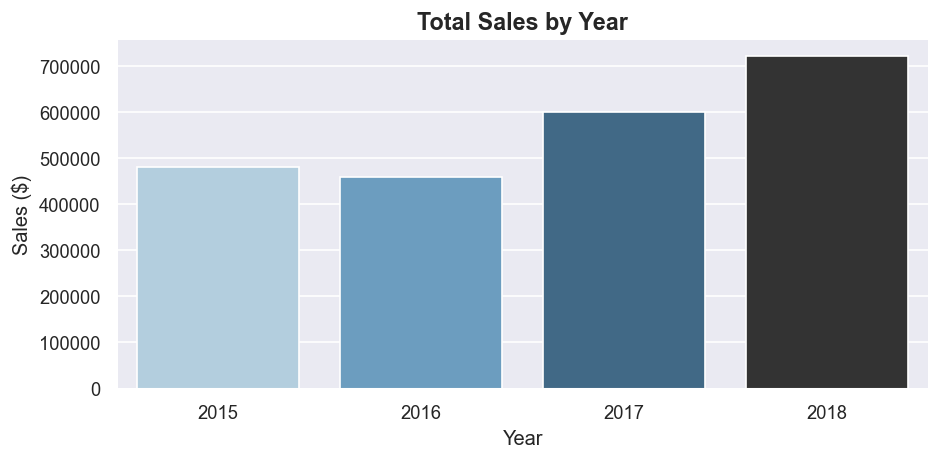

In [32]:
# Sales by year (bar chart)
plt.figure(figsize=(8, 4))
sns.barplot(data=yearly_sales, x="Year", y="Sales", hue="Year", palette="Blues_d",legend=False)
plt.title("Total Sales by Year", fontsize=14, fontweight="bold")
plt.ylabel("Sales ($)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

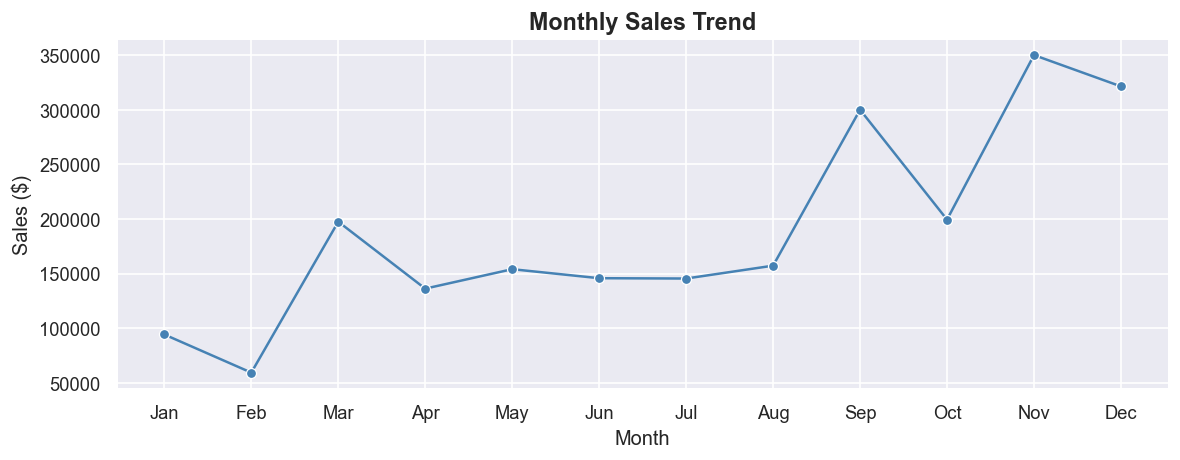

In [27]:
# monthly sales trend (line chart)
monthly_total = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_total, x="Month", y="Sales", marker="o", color="steelblue")
plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.ylabel("Sales ($)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

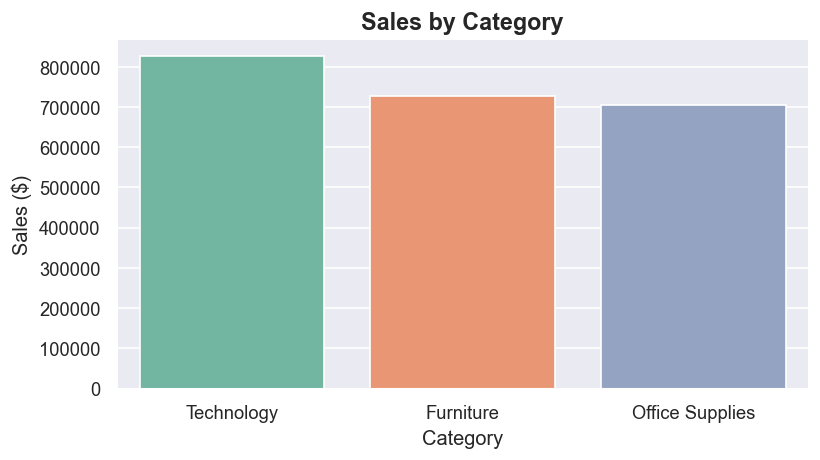

In [33]:
# sales by category
plt.figure(figsize=(7, 4))
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette="Set2",legend=False)
plt.title("Sales by Category", fontsize=14, fontweight="bold")
plt.ylabel("Sales ($)")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

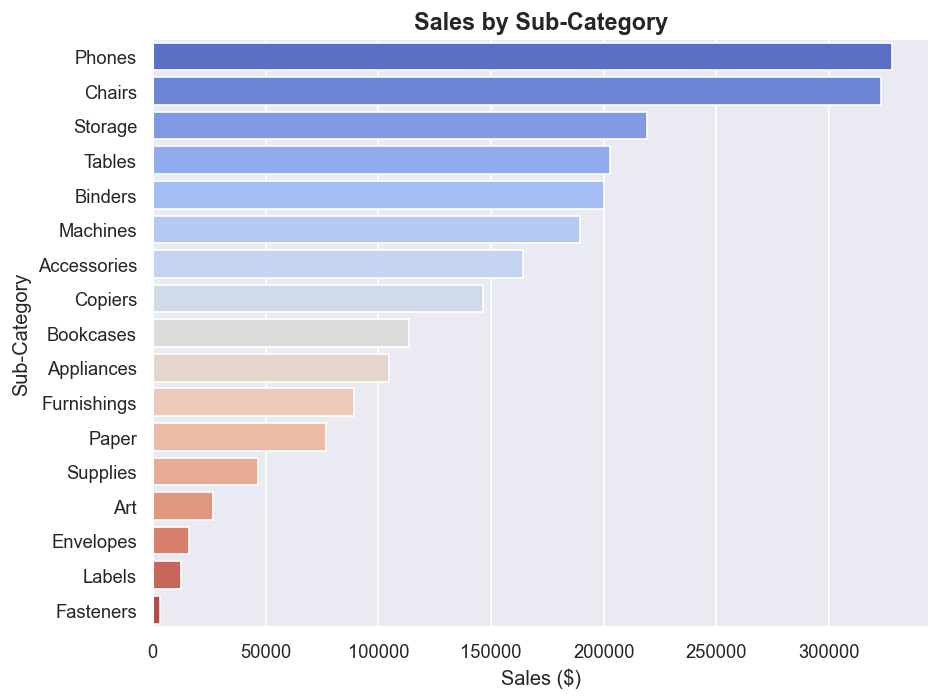

In [31]:
# sales by sub category (horizontal bar)
plt.figure(figsize=(8, 6))
sns.barplot(x=subcategory_sales.values, y=subcategory_sales.index, hue=subcategory_sales.index, palette="coolwarm", legend=False)
plt.title("Sales by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Sales ($)")
plt.tight_layout()
plt.show()

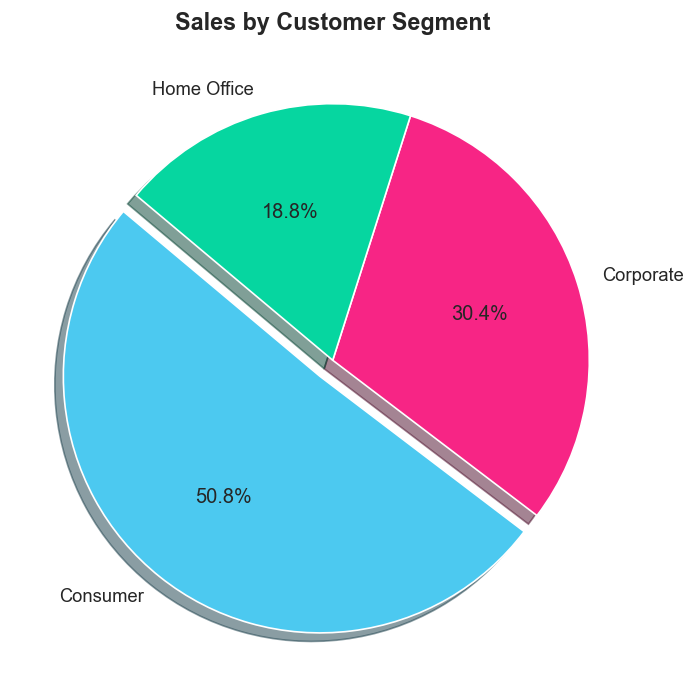

In [38]:
# sales by segment
explode=(0.08,0,0)

plt.figure(figsize=(6, 6))
plt.pie(segment_sales.values, labels=segment_sales.index,
        autopct="%1.1f%%", startangle=140, explode=explode,
        colors=["#4cc9f0", "#f72585", "#06d6a0"], shadow=True)
plt.title("Sales by Customer Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

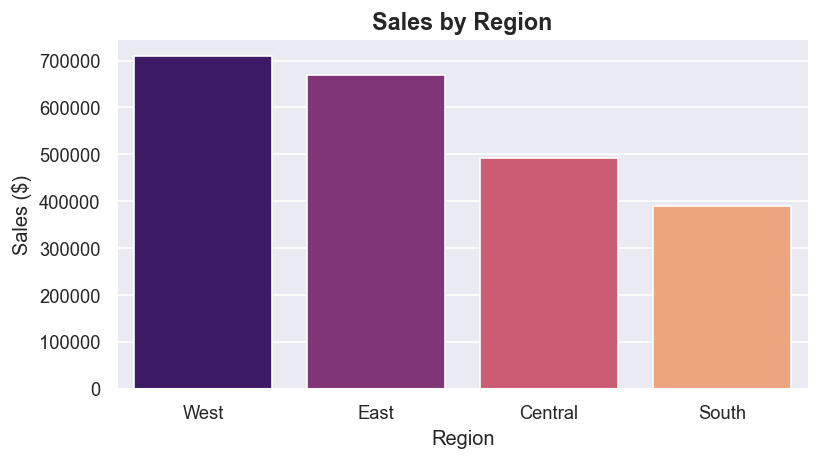

In [40]:
# sales by region

plt.figure(figsize=(7, 4))
sns.barplot(x=region_sales.index, y=region_sales.values,hue=region_sales.index, palette="magma", legend=False)
plt.title("Sales by Region", fontsize=14, fontweight="bold")
plt.ylabel("Sales ($)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

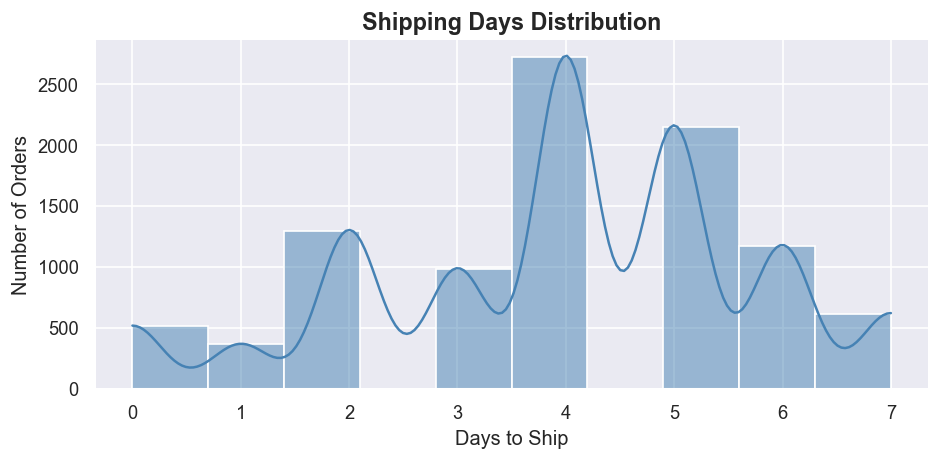

In [41]:
# shipping days distribution

plt.figure(figsize=(8, 4))
sns.histplot(df["Shipping Days"], bins=10, kde=True, color="steelblue")
plt.title("Shipping Days Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Days to Ship")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

FINAL SUMMARY STATS:

In [42]:
# Growth rate year over year
yearly_sales["Growth %"] = yearly_sales["Sales"].pct_change() * 100
print(yearly_sales)

   Year        Sales   Growth %
0  2015  479856.2081        NaN
1  2016  459436.0054  -4.255484
2  2017  600192.5500  30.636812
3  2018  722052.0192  20.303396


In [43]:
yearly_category = df.groupby(["Year", "Category"])["Sales"]\
                    .sum().unstack().round(2)
print(yearly_category)

Category  Furniture  Office Supplies  Technology
Year                                            
2015      156477.88        149512.82   173865.51
2016      164053.87        133124.41   162257.73
2017      195813.04        182417.57   221961.94
2018      212313.79        240367.54   269370.69


In [44]:
yearly_region = df.groupby(["Year", "Region"])["Sales"]\
                    .sum().unstack().round(2)
print(yearly_region)

Region    Central       East      South       West
Year                                              
2015    102920.52  127652.82  103374.91  145907.96
2016    102425.17  153225.18   70076.08  133709.57
2017    145673.88  178511.54   93535.90  182471.23
2018    141627.34  210129.19  122164.57  248130.93


In [45]:
# Best and worst months

monthly_total = df.groupby("Month")["Sales"].sum().reset_index()
monthly_total["Month Name"] = ["Jan","Feb","Mar","Apr","May","Jun",
                                "Jul","Aug","Sep","Oct","Nov","Dec"]

best_month  = monthly_total.loc[monthly_total["Sales"].idxmax(), "Month Name"]
worst_month = monthly_total.loc[monthly_total["Sales"].idxmin(), "Month Name"]

print("Best Month: ", best_month)
print("Worst Month:", worst_month)

Best Month:  Nov
Worst Month: Feb


In [46]:
# top 5 sub-categories
top5 = subcategory_sales.head()
print("Top 5 Sub-Categories by Sales:")
print(top5)


Top 5 Sub-Categories by Sales:
Sub-Category
Phones     327782.448
Chairs     322822.731
Storage    219343.392
Tables     202810.628
Binders    200028.785
Name: Sales, dtype: float64


In [47]:
# average shippingf by ship mode

ship_analysis = df.groupby("Ship Mode")["Shipping Days"].mean().round(2)
print("Average Shipping Days by Ship Mode:")
print(ship_analysis)

Average Shipping Days by Ship Mode:
Ship Mode
First Class       2.18
Same Day          0.04
Second Class      3.25
Standard Class    5.01
Name: Shipping Days, dtype: float64


In [48]:
# Regional breakdown by category

region_category = df.groupby(["Region", "Category"])["Sales"]\
                    .sum().unstack().round(2)
print(region_category)

Category  Furniture  Office Supplies  Technology
Region                                          
Central   160317.46        163590.24   168739.21
East      206461.39        199940.81   263116.53
South     116531.48        124424.77   148195.21
West      245348.25        217466.51   247404.93


FINAL INSIGHT SUMMARY

In [49]:
print("=" * 55)
print("        BUSINESS INSIGHTS SUMMARY")
print("=" * 55)

total   = df["Sales"].sum()
growth  = yearly_sales["Growth %"].iloc[-1]
top_sub = subcategory_sales.idxmax()
avg_ship= df["Shipping Days"].mean()

print(f"""
📊 OVERVIEW
   Total Revenue  : ${total:,.2f}
   YoY Growth     : {growth:.1f}%
   Total Orders   : {df["Order ID"].nunique():,}
   Total Customers: {df["Customer ID"].nunique():,}

📈 SALES TRENDS
   ✅ Business has grown consistently year over year
   ✅ Peak season is November & December (holiday demand)
   ⚠️  Slowest month is {worst_month} — marketing opportunity

🏆 TOP PERFORMERS
   ✅ Best Category    : Technology
   ✅ Best Sub-Category: {top_sub}
   ✅ Best Region      : West
   ✅ Best Segment     : Corporate

🚚 SHIPPING PERFORMANCE
   ✅ Average shipping time: {avg_ship:.1f} days
   ✅ Most orders delivered within 4-5 days

💡 BUSINESS RECOMMENDATIONS
   1. Increase marketing budget in Nov & Dec to 
      capitalize on peak season demand
   2. Investigate low sales months and launch 
      promotions to boost revenue
   3. Focus corporate segment campaigns in the 
      West region for maximum ROI
   4. Expand Technology & Phones inventory as 
      they are the strongest revenue drivers
""")
print("=" * 55)

        BUSINESS INSIGHTS SUMMARY

📊 OVERVIEW
   Total Revenue  : $2,261,536.78
   YoY Growth     : 20.3%
   Total Orders   : 4,922
   Total Customers: 793

📈 SALES TRENDS
   ✅ Business has grown consistently year over year
   ✅ Peak season is November & December (holiday demand)
   ⚠️  Slowest month is Feb — marketing opportunity

🏆 TOP PERFORMERS
   ✅ Best Category    : Technology
   ✅ Best Sub-Category: Phones
   ✅ Best Region      : West
   ✅ Best Segment     : Corporate

🚚 SHIPPING PERFORMANCE
   ✅ Average shipping time: 4.0 days
   ✅ Most orders delivered within 4-5 days

💡 BUSINESS RECOMMENDATIONS
   1. Increase marketing budget in Nov & Dec to 
      capitalize on peak season demand
   2. Investigate low sales months and launch 
      promotions to boost revenue
   3. Focus corporate segment campaigns in the 
      West region for maximum ROI
   4. Expand Technology & Phones inventory as 
      they are the strongest revenue drivers

